In [1]:
# Bank Marketing Prediction using Decision Tree
# This notebook builds a Decision Tree classifier to predict whether a customer
# will subscribe to a term deposit based on bank marketing data.

In [2]:
# Objective:
# To train and evaluate a Decision Tree model on the Bank Marketing dataset
# and predict whether a client will subscribe to a term deposit (y = yes/no).

In [ ]:
##Import Libraries

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
    roc_curve
)

In [ ]:
##Load Dataset

In [4]:
df = pd.read_csv("bank-full.csv", sep=';')
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


In [ ]:
##Explore Dataset

In [5]:
print("Shape of dataset:", df.shape)
print("\nColumns:")
print(df.columns)

print("\nData types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isnull().sum())

print("\nFirst 5 rows:")
display(df.head())

Shape of dataset: (45211, 17)

Columns:
Index(['age', 'job', 'marital', 'education', 'default', 'balance', 'housing',
       'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'y'],
      dtype='object')

Data types:
age           int64
job          object
marital      object
education    object
default      object
balance       int64
housing      object
loan         object
contact      object
day           int64
month        object
duration      int64
campaign      int64
pdays         int64
previous      int64
poutcome     object
y            object
dtype: object

Missing values:
age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
y            0
dtype: int64

First 5 rows:


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


In [ ]:
##Dataset Size and Target Distribution

In [6]:
print("Dataset size:", df.shape)
print("\nTarget distribution:")
print(df['y'].value_counts())
print("\nTarget distribution (percentage):")
print(df['y'].value_counts(normalize=True) * 100)

Dataset size: (45211, 17)

Target distribution:
y
no     39922
yes     5289
Name: count, dtype: int64

Target distribution (percentage):
y
no     88.30152
yes    11.69848
Name: proportion, dtype: float64


In [ ]:
##Visualization of target distribution

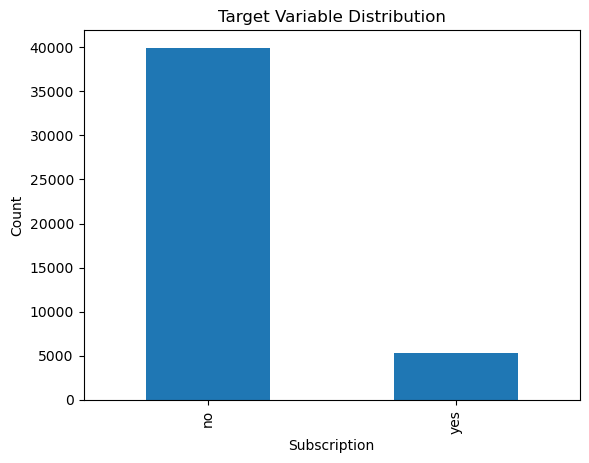

In [7]:
df['y'].value_counts().plot(kind='bar')
plt.title("Target Variable Distribution")
plt.xlabel("Subscription")
plt.ylabel("Count")
plt.show()

In [ ]:
##Describe Dataset Attributes

In [8]:
df.describe(include='all')

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
count,45211.000000,45211,45211,45211,45211,45211.000000,45211,45211,45211,45211.000000,45211,45211.000000,45211.000000,45211.000000,45211.000000,45211,45211
unique,NaN,12,3,4,2,NaN,2,2,3,NaN,12,NaN,NaN,NaN,NaN,4,2
top,NaN,blue-collar,married,secondary,no,NaN,yes,no,cellular,NaN,may,NaN,NaN,NaN,NaN,unknown,no
freq,NaN,9732,27214,23202,44396,NaN,25130,37967,29285,NaN,13766,NaN,NaN,NaN,NaN,36959,39922
mean,40.936210,NaN,NaN,NaN,NaN,1362.272058,NaN,NaN,NaN,15.806419,NaN,258.163080,2.763841,40.197828,0.580323,NaN,NaN
std,10.618762,NaN,NaN,NaN,NaN,3044.765829,NaN,NaN,NaN,8.322476,NaN,257.527812,3.098021,100.128746,2.303441,NaN,NaN
min,18.000000,NaN,NaN,NaN,NaN,-8019.000000,NaN,NaN,NaN,1.000000,NaN,0.000000,1.000000,-1.000000,0.000000,NaN,NaN
25%,33.000000,NaN,NaN,NaN,NaN,72.000000,NaN,NaN,NaN,8.000000,NaN,103.000000,1.000000,-1.000000,0.000000,NaN,NaN
50%,39.000000,NaN,NaN,NaN,NaN,448.000000,NaN,NaN,NaN,16.000000,NaN,180.000000,2.000000,-1.000000,0.000000,NaN,NaN
75%,48.000000,NaN,NaN,NaN,NaN,1428.000000,NaN,NaN,NaN,21.000000,NaN,319.000000,3.000000,-1.000000,0.000000,NaN,NaN


In [ ]:
##Feature and Target Separation

In [9]:
X = df.drop("y", axis=1)
y = df["y"]

In [ ]:
##Encode Target Variable

In [10]:
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y)   # no = 0, yes = 1

print("Encoded classes:", label_encoder.classes_)

Encoded classes: ['no' 'yes']


In [ ]:
##Identify Categorical and Numerical Features

In [11]:
categorical_features = X.select_dtypes(include=['object']).columns.tolist()
numerical_features = X.select_dtypes(exclude=['object']).columns.tolist()

print("Categorical features:", categorical_features)
print("Numerical features:", numerical_features)

Categorical features: ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome']
Numerical features: ['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']


In [ ]:
##Train-Test Split

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)

Training set shape: (36168, 16)
Testing set shape: (9043, 16)


In [ ]:
##Data Preprocessing

In [13]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median"))
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_transformer, numerical_features),
    ("cat", categorical_transformer, categorical_features)
])

In [ ]:
##Build Decision Tree Pipeline

In [14]:
dt_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", DecisionTreeClassifier(random_state=42))
])

In [ ]:
##Train the Decision Tree Model

In [15]:
dt_pipeline.fit(X_train, y_train)
print("Decision Tree model trained successfully.")

Decision Tree model trained successfully.


In [ ]:
##Model Prediction

In [16]:
y_pred = dt_pipeline.predict(X_test)
y_prob = dt_pipeline.predict_proba(X_test)[:, 1]

In [ ]:
##Model Evaluation

In [17]:
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.8745991374543846


In [ ]:
##Classification Report

In [18]:
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=["no", "yes"]))


Classification Report:
              precision    recall  f1-score   support

          no       0.93      0.93      0.93      7985
         yes       0.46      0.48      0.47      1058

    accuracy                           0.87      9043
   macro avg       0.70      0.70      0.70      9043
weighted avg       0.88      0.87      0.88      9043



In [ ]:
##Confusion Matrix

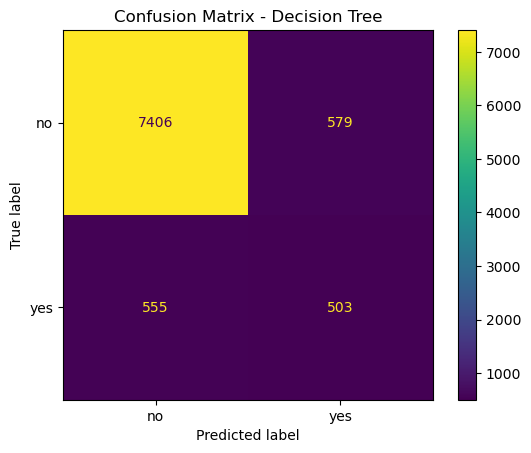

In [19]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["no", "yes"])
disp.plot()
plt.title("Confusion Matrix - Decision Tree")
plt.show()

In [ ]:
##ROC-AUC Evaluation

In [20]:
roc_auc = roc_auc_score(y_test, y_prob)
print("ROC-AUC Score:", roc_auc)

ROC-AUC Score: 0.7014571863832587


In [ ]:
##ROC Curve

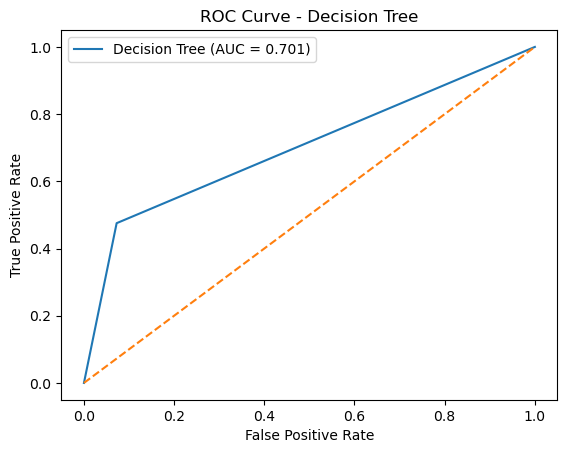

In [21]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.plot(fpr, tpr, label=f"Decision Tree (AUC = {roc_auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Decision Tree")
plt.legend()
plt.show()

In [ ]:
##Hyperparameter Tuning / Improved Model

In [22]:
param_grid = {
    "classifier__max_depth": [3, 5, 10, 15, None],
    "classifier__min_samples_split": [2, 5, 10, 20],
    "classifier__min_samples_leaf": [1, 2, 4, 8],
    "classifier__criterion": ["gini", "entropy"]
}

grid_search = GridSearchCV(
    dt_pipeline,
    param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("Best Parameters:", grid_search.best_params_)
print("Best Cross-Validation Score:", grid_search.best_score_)

Best Parameters: {'classifier__criterion': 'gini', 'classifier__max_depth': 5, 'classifier__min_samples_leaf': 1, 'classifier__min_samples_split': 2}
Best Cross-Validation Score: 0.9023723135457129


In [ ]:
##Evaluate Tuned Model

In [23]:
best_model = grid_search.best_estimator_

y_pred_best = best_model.predict(X_test)
y_prob_best = best_model.predict_proba(X_test)[:, 1]

best_accuracy = accuracy_score(y_test, y_pred_best)
best_roc_auc = roc_auc_score(y_test, y_prob_best)

print("Tuned Model Accuracy:", best_accuracy)
print("Tuned Model ROC-AUC:", best_roc_auc)

print("\nClassification Report for Tuned Model:")
print(classification_report(y_test, y_pred_best, target_names=["no", "yes"]))

Tuned Model Accuracy: 0.8994802609753401
Tuned Model ROC-AUC: 0.8571514642885465

Classification Report for Tuned Model:
              precision    recall  f1-score   support

          no       0.91      0.98      0.95      7985
         yes       0.65      0.31      0.42      1058

    accuracy                           0.90      9043
   macro avg       0.78      0.64      0.68      9043
weighted avg       0.88      0.90      0.88      9043



In [ ]:
##Confusion Matrix for Tuned Model

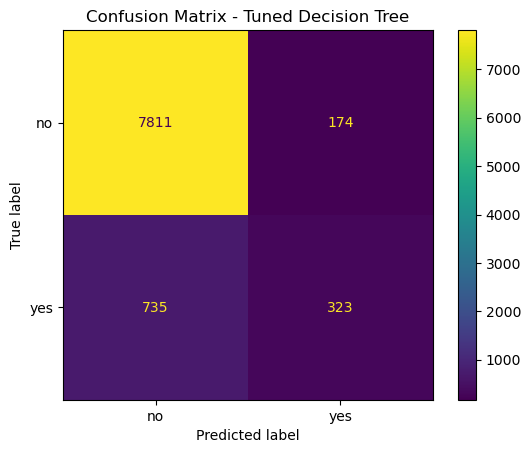

In [24]:
cm_best = confusion_matrix(y_test, y_pred_best)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_best, display_labels=["no", "yes"])
disp.plot()
plt.title("Confusion Matrix - Tuned Decision Tree")
plt.show()

In [ ]:
##ROC Curve for Tuned Model

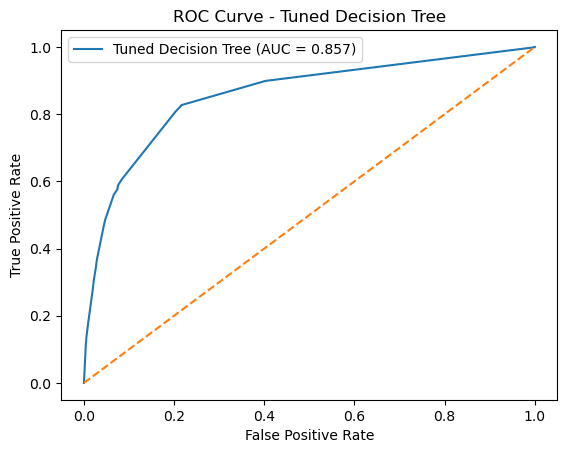

In [25]:
fpr_best, tpr_best, thresholds_best = roc_curve(y_test, y_prob_best)

plt.plot(fpr_best, tpr_best, label=f"Tuned Decision Tree (AUC = {best_roc_auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Tuned Decision Tree")
plt.legend()
plt.show()

In [ ]:
##Feature Importance

In [26]:
best_clf = best_model.named_steps["classifier"]
ohe = best_model.named_steps["preprocessor"].named_transformers_["cat"].named_steps["onehot"]

encoded_cat_features = ohe.get_feature_names_out(categorical_features)
all_feature_names = numerical_features + list(encoded_cat_features)

importances = best_clf.feature_importances_

feature_importance_df = pd.DataFrame({
    "Feature": all_feature_names,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

feature_importance_df.head(10)

,Feature,Importance
3,duration,0.549058
49,poutcome_success,0.296878
28,housing_no,0.044160
0,age,0.027036
5,pdays,0.017365
42,month_mar,0.016698
34,contact_unknown,0.011558
45,month_oct,0.010165
29,housing_yes,0.005769
43,month_may,0.005021


In [ ]:
##Plot top 10 important features

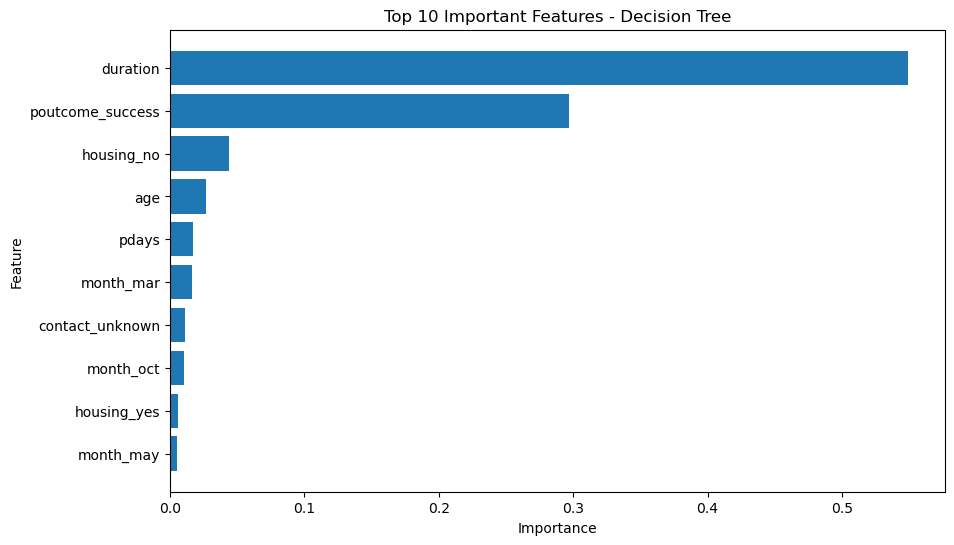

In [27]:
top10 = feature_importance_df.head(10)

plt.figure(figsize=(10, 6))
plt.barh(top10["Feature"], top10["Importance"])
plt.gca().invert_yaxis()
plt.title("Top 10 Important Features - Decision Tree")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

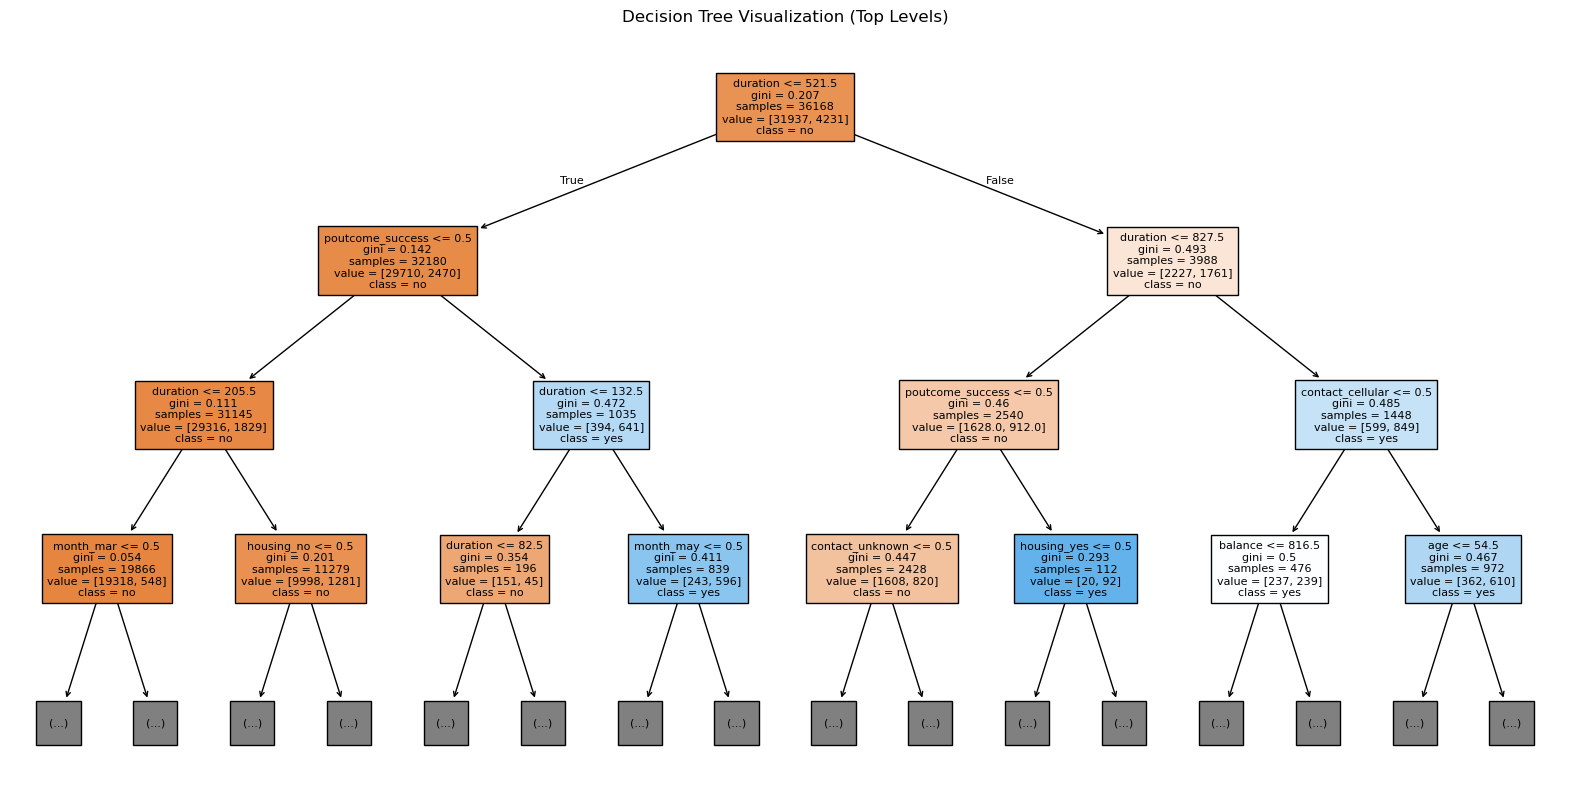

In [28]:
plt.figure(figsize=(20, 10))
plot_tree(
    best_clf,
    max_depth=3,
    feature_names=all_feature_names,
    class_names=["no", "yes"],
    filled=True,
    fontsize=8
)
plt.title("Decision Tree Visualization (Top Levels)")
plt.show()

In [ ]:
##Optional: Visualize the Decision Tree

In [29]:
# Important Observation
# The dataset is imbalanced because the number of "no" responses is much larger
# than the number of "yes" responses. Because of that, accuracy alone is not enough.
# ROC-AUC, confusion matrix, precision, recall and F1-score are also important.

In [30]:
# Interpretation of Visualizations
# 1. The target distribution bar chart shows class imbalance.
# 2. The confusion matrix shows how many customers were correctly and incorrectly classified.
# 3. The ROC curve shows the model's ability to separate the two classes.
# 4. The feature importance plot shows which features most influenced the model.

In [31]:
# Conclusion
# A Decision Tree classifier was trained on the Bank Marketing dataset to predict
# whether a customer subscribes to a term deposit.
# The model was evaluated using accuracy, confusion matrix, classification report,
# and ROC-AUC score.
# Hyperparameter tuning improved the model performance compared to the default model.
# Although the model performs reasonably well, class imbalance affects prediction quality.
# Future improvements may include class balancing techniques, pruning, and comparison
# with other algorithms such as Random Forest, Logistic Regression, and SVM.

In [32]:
##One Better Version for Imbalanced Data

In [33]:
dt_pipeline_balanced = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", DecisionTreeClassifier(class_weight="balanced", random_state=42))
])

dt_pipeline_balanced.fit(X_train, y_train)

y_pred_bal = dt_pipeline_balanced.predict(X_test)
y_prob_bal = dt_pipeline_balanced.predict_proba(X_test)[:, 1]

print("Balanced Decision Tree Accuracy:", accuracy_score(y_test, y_pred_bal))
print("Balanced Decision Tree ROC-AUC:", roc_auc_score(y_test, y_prob_bal))
print(classification_report(y_test, y_pred_bal, target_names=["no", "yes"]))

Balanced Decision Tree Accuracy: 0.8776954550481035
Balanced Decision Tree ROC-AUC: 0.6917312470333672
              precision    recall  f1-score   support

          no       0.93      0.93      0.93      7985
         yes       0.48      0.45      0.46      1058

    accuracy                           0.88      9043
   macro avg       0.70      0.69      0.70      9043
weighted avg       0.87      0.88      0.88      9043

